# 

title: Water Rights Restored to the Gila River

subtitle: The impacts of irrigation on vegetation health in the Gila
River Valley

author:

-   Elsa Culler

-   Nate Quarderer

date: last-modified

image: /img/earth-analytics/water-rights/lesson-water-rights.png

image-alt: “Dry river with dead plants turns into a stream with living
plants”

description: \|

In 2004, the Akimel O’‘otham and Tohono O’’odham tribes won a water
rights settlement in the US Supreme Court. Using satellite imagery, we
can see the effects of irrigation water on the local vegetation.

learning-goals:

-   Open raster or image data using code

-   Combine raster data and vector data to crop images to an area of
    interest

-   Summarize raster values with stastics

-   Analyze a time-series of raster images

params:

id: stars

site_name: Gila River Indian Community

event: water rights case

data_dir: gila-river

jupyter:

kernelspec:

    name: learning-portal

    language: python

    display_name: Learning Portal

# STEP 0: Set up

To get started on this notebook, you’ll need to restore any variables
from previous notebooks to your workspace. To save time and memory, make
sure to specify which variables you want to load.

In [14]:
%store -r ndvi_das ndvi_xr boundary_gdf gdf

You will also need to import any libraries you are using in this
notebook, since they won’t carry over from the previous notebook:

In [29]:
# Import libraries

import hvplot.xarray
import hvplot.pandas
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import pandas as pd
import rioxarray

from shapely.geometry import box

# STEP 3: Plot NDVI

<link rel="stylesheet" type="text/css" href="./assets/styles.css"><div class="callout callout-style-default callout-titled callout-task"><div class="callout-header"><div class="callout-icon-container"><i class="callout-icon"></i></div><div class="callout-title-container flex-fill">Try It: Plot the change in NDVI spatially</div></div><div class="callout-body-container callout-body"><p>Complete the following:</p>
<ul>
<li>Select data from 2021 to 2023 (3 years after the <span
data-__quarto_custom="true" data-__quarto_custom_type="Shortcode"
data-__quarto_custom_context="Inline"
data-__quarto_custom_id="1"></span>)</li>
<li>Take the temporal mean (over the <strong>date</strong>, not
spatially)</li>
<li>Get the NDVI variable (should be a DataArray, not a Dataset)</li>
<li>Repeat for the data from 2018 to 2020 (3 years before the <span
data-__quarto_custom="true" data-__quarto_custom_type="Shortcode"
data-__quarto_custom_context="Inline"
data-__quarto_custom_id="2"></span>)</li>
<li>Subtract the 2018-2020 time period <strong>from</strong> the
2021-2023 time period</li>
<li>Plot the result using a <strong>diverging</strong> color map like
<code>cmap=plt.cm.PiYG</code></li>
</ul>
<p>There are different types of color maps for different types of data.
In this case, we want decreases to be a different color from increases,
so we should use a <strong>diverging</strong> color map. Check out
available colormaps in the <a
href="https://matplotlib.org/stable/tutorials/colors/colormaps.html">matplotlib
documentation</a>.</p></div></div>

<link rel="stylesheet" type="text/css" href="./assets/styles.css"><div class="callout callout-style-default callout-titled callout-extra"><div class="callout-header"><div class="callout-icon-container"><i class="callout-icon"></i></div><div class="callout-title-container flex-fill">Looking for an Extra Challenge?</div></div><div class="callout-body-container callout-body"><p>For an extra challenge, add the <span data-__quarto_custom="true"
data-__quarto_custom_type="Shortcode"
data-__quarto_custom_context="Inline"
data-__quarto_custom_id="3"></span> boundary to the plot.</p></div></div>

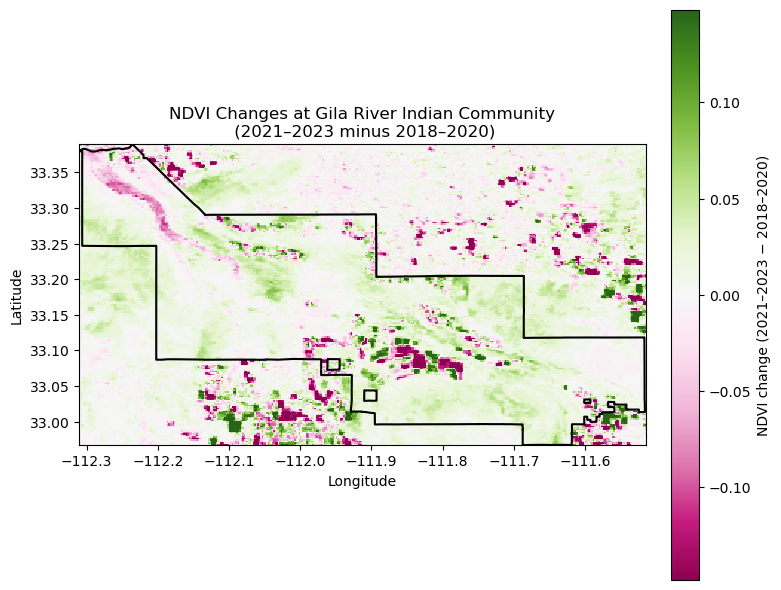

In [16]:
# Plot NDVI change (2021–2023 minus 2018–2020) with boundary overlay

# 1) Ensure DataArray; 2) temporal means; 3) difference
ndvi_da   = ndvi_xr["NDVI"] if hasattr(ndvi_xr, "data_vars") and "NDVI" in ndvi_xr.data_vars else ndvi_xr
ndvi_post = ndvi_da.sel(date=slice("2021","2023")).mean(dim="date", skipna=True)
ndvi_pre  = ndvi_da.sel(date=slice("2018","2020")).mean(dim="date", skipna=True)
ndvi_diff = (ndvi_post - ndvi_pre).squeeze(drop=True)

# 4) Reproject to WGS84 (copy CRS/transform if math dropped them)
import rioxarray
if getattr(ndvi_diff.rio, "crs", None) is None:
    ref = ndvi_da.isel(date=0)
    ndvi_diff = ndvi_diff.rio.write_crs(ref.rio.crs).rio.write_transform(ref.rio.transform())
ndvi_diff_4326 = ndvi_diff.rio.reproject("EPSG:4326")

# 5) Plot with diverging colormap (PiYG) + EXTRA: boundary overlay
vals  = ndvi_diff_4326.values
finite = vals[np.isfinite(vals)]
vmax  = float(np.nanpercentile(np.abs(finite), 98)) if finite.size else 0.3
vmin  = -vmax
xmin, ymin, xmax, ymax = ndvi_diff_4326.rio.bounds()

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(vals, cmap=plt.cm.PiYG, vmin=vmin, vmax=vmax,
               extent=(xmin, xmax, ymin, ymax), origin="upper", interpolation="nearest")
boundary_gdf.to_crs(4326).plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1.5)
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04); cbar.set_label("NDVI change (2021–2023 − 2018–2020)")
ax.set_aspect("equal", adjustable="box")
ax.set_title("NDVI Changes at Gila River Indian Community\n (2021–2023 minus 2018–2020)")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
plt.show()


In [30]:
# 1. Work in the same CRS as boundary_gdf
boundary_gdf_proj = boundary_gdf.to_crs(boundary_gdf.crs)

# 2. Make a bounding box a little bigger than GRIC
minx, miny, maxx, maxy = boundary_gdf_proj.total_bounds

pad = 0.2  # degrees; adjust if you want a bigger context
outer_box = box(minx - pad, miny - pad, maxx + pad, maxy + pad)

# 3. Subtract GRIC from the big box → "outside" ring
outside_geom = outer_box.difference(boundary_gdf_proj.unary_union)

outside_gdf = gpd.GeoDataFrame(
    geometry=[outside_geom],
    crs=boundary_gdf_proj.crs,
)

outside_gdf

/tmp/ipykernel_14148/3724257270.py:11: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  outside_geom = outer_box.difference(boundary_gdf_proj.unary_union)


,geometry
0,"MULTIPOLYGON (((-112.50875 32.76704, -112.5087..."


In [31]:
gdf = outside_gdf

In [32]:
# Start from the NDVI DataArray
ndvi_da = ndvi_xr["NDVI"] if hasattr(ndvi_xr, "data_vars") and "NDVI" in ndvi_xr.data_vars else ndvi_xr

# Ensure NDVI has a CRS
if getattr(ndvi_da.rio, "crs", None) is None:
    ndvi_da = ndvi_da.rio.write_crs("EPSG:4326")  # or the correct CRS for your rasters

# Reproject the polygons to match the NDVI CRS
boundary_gdf_proj = boundary_gdf.to_crs(ndvi_da.rio.crs)
gdf_proj = gdf.to_crs(ndvi_da.rio.crs)

# Clip to GRIC boundary (inside region)
ndvi_inside = ndvi_da.rio.clip(
    boundary_gdf_proj.geometry,
    drop=True,
    from_disk=False,
)

# Clip to outside comparison region
ndvi_outside = ndvi_da.rio.clip(
    gdf_proj.geometry,
    drop=True,
    from_disk=False,
)

print("ndvi_inside non-NaN count:", int(np.isfinite(ndvi_inside.values).sum()))
print("ndvi_outside non-NaN count:", int(np.isfinite(ndvi_outside.values).sum()))

ndvi_inside non-NaN count: 5195774
ndvi_outside non-NaN count: 6746278


In [33]:
# Collapse each region to a spatial mean time series
ndvi_inside_mean = ndvi_inside.mean(dim=("y", "x"), skipna=True)
ndvi_outside_mean = ndvi_outside.mean(dim=("y", "x"), skipna=True)

# Convert to tidy DataFrames (use a clear name for the value column)
inside_df = (
    ndvi_inside_mean
    .to_dataframe(name="ndvi")         # create a DataFrame with column 'ndvi'
    .reset_index()[["date", "ndvi"]]
)
inside_df["region"] = "Inside GRIC"

outside_df = (
    ndvi_outside_mean
    .to_dataframe(name="ndvi")
    .reset_index()[["date", "ndvi"]]
)
outside_df["region"] = "Outside GRIC"

# Combine into a single table
ndvi_df = pd.concat([inside_df, outside_df], ignore_index=True)

print("Rows per region:")
print(ndvi_df["region"].value_counts())

print("\nUnique regions in monthly_mean:")
print(monthly_mean["region"].unique())

print("Inside non-NaN:", int(np.isfinite(ndvi_inside.values).sum()))
print("Outside non-NaN:", int(np.isfinite(ndvi_outside.values).sum()))

# Convenience columns
ndvi_df["year"] = ndvi_df["date"].dt.year
ndvi_df["month"] = ndvi_df["date"].dt.month

ndvi_df.head()

Rows per region:
region
Inside GRIC     154
Outside GRIC    154
Name: count, dtype: int64

Unique regions in monthly_mean:
['Inside GRIC' 'Outside GRIC']
Inside non-NaN: 5195774
Outside non-NaN: 6746278


,date,ndvi,region,year,month
0,2001-05-25,0.192720,Inside GRIC,2001,5
1,2001-06-10,0.183816,Inside GRIC,2001,6
2,2001-06-26,0.193380,Inside GRIC,2001,6
3,2001-07-12,0.206413,Inside GRIC,2001,7
4,2001-07-28,0.205277,Inside GRIC,2001,7


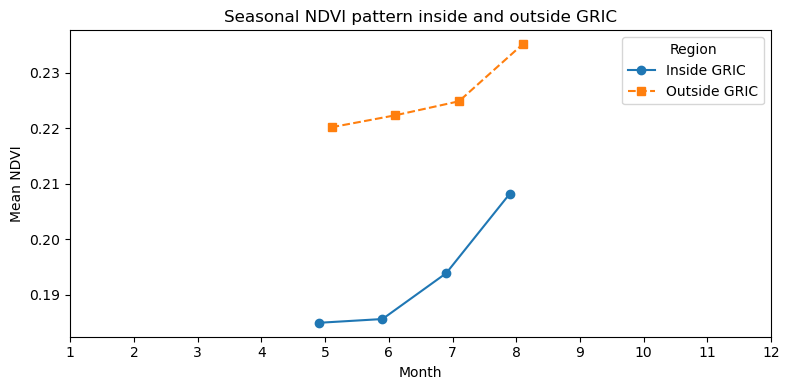

In [34]:
# Mean NDVI by month across all years, for each region
monthly_mean = (
    ndvi_df.groupby(["region", "month"])["ndvi"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 4))

for region, sub in monthly_mean.groupby("region"):
    # Slight x-offset so points don't sit exactly on top of each other
    if region == "Inside GRIC":
        x = sub["month"] - 0.1
        style = dict(marker="o", linestyle="-", color="tab:blue")
    else:
        x = sub["month"] + 0.1
        style = dict(marker="s", linestyle="--", color="tab:orange")

    ax.plot(
        x,
        sub["ndvi"],
        label=region,
        **style,
    )

ax.set_xlabel("Month")
ax.set_ylabel("Mean NDVI")
ax.set_title("Seasonal NDVI pattern inside and outside GRIC")
ax.set_xticks(range(1, 13))
ax.set_xlim(1, 12)
ax.legend(title="Region")

fig.tight_layout()
plt.show()

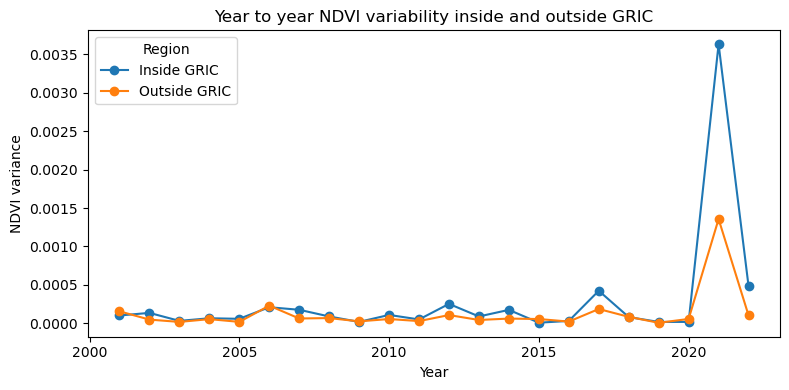

In [35]:
# Compute annual mean and variance of NDVI for each region
yearly_stats = (
    ndvi_df.groupby(["region", "year"])["ndvi"]
    .agg(["mean", "var"])
    .reset_index()
    .rename(columns={"var": "ndvi_var"})
)

fig, ax = plt.subplots(figsize=(8, 4))

for region, sub in yearly_stats.groupby("region"):
    ax.plot(
        sub["year"],
        sub["ndvi_var"],
        marker="o",
        label=region,
    )

ax.set_xlabel("Year")
ax.set_ylabel("NDVI variance")
ax.set_title("Year to year NDVI variability inside and outside GRIC")
ax.legend(title="Region")

fig.tight_layout()
plt.show()

# STEP -1: Wrap up

Don’t forget to store your variables so you can use them in other
notebooks! Replace `var1` and `var2` with the variable you want to save,
separated by spaces.

In [ ]:
%store ndvi_diff_4326 ndvi_inside ndvi_outside ndvi_df monthly_mean yearly_stats

Finally, be sure to `Restart` and `Run all` to make sure your notebook
works all the way through!